# 6. 채널정보 (채널 정보) EDA

카테고리 6 = **어떤 창구로 접촉하나 (채널 활동량)**. 105개 컬럼이지만 **절반 이상이 상수**(이 표본에서 카운트가 전부 0) → 정보 밀도가 낮은 카테고리. 라벨은 회원정보에서 조인.

**사전 발견**: Segment는 이용/가치 등급(A상위~E하위) 순서형. 채널 활동은 소비만큼 강하진 않아도, **E(휴면)는 접촉이 거의 없고 이용 고객일수록 디지털 채널 활동↑** 패턴이 예상됨. B(할부 고소비)의 특이 접촉 여부도 확인.

**컬럼 구조**: ARS 인입, 웹/앱/모바일 방문(횟수·일수·월수, 일부는 '1회이상/10회이상' 구간 문자열), IB(인바운드) 문의·상담(대부분 0=상수), 당사멤버십 방문, 홈페이지 금융/선결제, OS구분(Android/IOS).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family']='Malgun Gothic'; plt.rcParams['axes.unicode_minus']=False
pd.set_option('display.max_columns',200); pd.set_option('display.width',220)
import glob, os
ROOT = os.path.abspath(os.path.join(os.getcwd(),'..')) if os.path.basename(os.getcwd())=='eda' else os.getcwd()
MONTH='201812'; SEG_ORDER=['A','B','C','D','E']
SEG_COLORS={'A':'#d1495b','B':'#edae49','C':'#66a182','D':'#2e4057','E':'#8d96a3'}
print('ROOT =', ROOT)

ROOT = C:\Users\82109\Desktop\DACON


## 1. 데이터 로드 (201812 채널) + 라벨 조인

In [2]:
f6 = glob.glob(os.path.join(ROOT,'train','6.*',f'{MONTH}_*.parquet'))[0]
df = pd.read_parquet(f6)
lbl = pd.read_parquet(glob.glob(os.path.join(ROOT,'train','1.*',f'{MONTH}_*.parquet'))[0], columns=['ID','Segment'])
df = df.merge(lbl, on='ID', how='left')
assert df['Segment'].notna().all()
print('shape:', df.shape); df.head(3)

shape: (400000, 106)


,기준년월,ID,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M,인입일수_ARS_R6M,인입월수_ARS_R6M,인입후경과월_ARS,인입횟수_ARS_B0M,이용메뉴건수_ARS_B0M,인입일수_ARS_B0M,방문횟수_PC_R6M,방문일수_PC_R6M,방문월수_PC_R6M,방문후경과월_PC_R6M,방문횟수_앱_R6M,방문일수_앱_R6M,방문월수_앱_R6M,방문후경과월_앱_R6M,방문횟수_모바일웹_R6M,방문일수_모바일웹_R6M,방문월수_모바일웹_R6M,방문후경과월_모바일웹_R6M,방문횟수_PC_B0M,방문일수_PC_B0M,방문횟수_앱_B0M,방문일수_앱_B0M,방문횟수_모바일웹_B0M,방문일수_모바일웹_B0M,인입횟수_IB_R6M,인입횟수_금융_IB_R6M,인입일수_IB_R6M,인입월수_IB_R6M,이용메뉴건수_IB_R6M,인입후경과월_IB_R6M,인입횟수_IB_B0M,인입일수_IB_B0M,이용메뉴건수_IB_B0M,인입불만횟수_IB_R6M,인입불만일수_IB_R6M,인입불만월수_IB_R6M,인입불만후경과월_IB_R6M,인입불만횟수_IB_B0M,인입불만일수_IB_B0M,상담건수_B0M,IB문의건수_사용승인내역_B0M,IB문의건수_한도_B0M,IB문의건수_선결제_B0M,IB문의건수_결제_B0M,IB문의건수_할부_B0M,IB문의건수_정보변경_B0M,IB문의건수_결제일변경_B0M,IB문의건수_명세서_B0M,IB문의건수_비밀번호_B0M,IB문의건수_SMS_B0M,IB문의건수_APP_B0M,IB문의건수_부대서비스_B0M,IB문의건수_포인트_B0M,IB문의건수_카드발급_B0M,IB문의건수_BL_B0M,IB문의건수_분실도난_B0M,IB문의건수_CA_B0M,IB문의건수_CL_RV_B0M,IB문의건수_CS_B0M,IB상담건수_VOC_B0M,IB상담건수_VOC민원_B0M,IB상담건수_VOC불만_B0M,IB상담건수_금감원_B0M,상담건수_R6M,IB문의건수_사용승인내역_R6M,IB문의건수_한도_R6M,IB문의건수_선결제_R6M,IB문의건수_결제_R6M,IB문의건수_할부_R6M,IB문의건수_정보변경_R6M,IB문의건수_결제일변경_R6M,IB문의건수_명세서_R6M,IB문의건수_비밀번호_R6M,IB문의건수_SMS_R6M,IB문의건수_APP_R6M,IB문의건수_부대서비스_R6M,IB문의건수_포인트_R6M,IB문의건수_카드발급_R6M,IB문의건수_BL_R6M,IB문의건수_분실도난_R6M,IB문의건수_CA_R6M,IB문의건수_CL_RV_R6M,IB문의건수_CS_R6M,IB상담건수_VOC_R6M,IB상담건수_VOC민원_R6M,IB상담건수_VOC불만_R6M,IB상담건수_금감원_R6M,불만제기건수_B0M,불만제기건수_R12M,불만제기후경과월_R12M,당사PAY_방문횟수_B0M,당사PAY_방문횟수_R6M,당사PAY_방문월수_R6M,당사멤버쉽_방문횟수_B0M,당사멤버쉽_방문횟수_R6M,당사멤버쉽_방문월수_R6M,OS구분코드,홈페이지_금융건수_R6M,홈페이지_선결제건수_R6M,홈페이지_금융건수_R3M,홈페이지_선결제건수_R3M,Segment
0,201812,TRAIN_000000,10회 이상,30회 이상,12,6,0,2,6,2,1회 이상,1회 이상,0,6,1회 이상,0,0,6,0,0,0,6,0,0,0,0,0,0,0,0,0,1,0,6,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0,0,0,23,136,6,Android,0,0,0,0,D
1,201812,TRAIN_000001,1회 이상,1회 이상,0,0,0,0,0,0,1회 이상,1회 이상,0,6,1회 이상,0,0,6,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,6,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0,0,0,0,0,0,NaN,0,0,0,0,E
2,201812,TRAIN_000002,1회 이상,1회 이상,1,1,5,0,0,0,20회 이상,20회 이상,1,1,40회 이상,37,6,0,0,0,0,6,0,4,8,7,0,0,2,0,1,1,1,5,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0,0,0,0,0,0,Android,12,10,6,6,C


## 2. 컬럼 개요 — dtype / 결측 / 카디널리티

In [3]:
meta = pd.DataFrame({'dtype':df.dtypes.astype(str),'n_missing':df.isna().sum(),
    'missing_%':(df.isna().mean()*100).round(2),'nunique':df.nunique(dropna=True)})
print('상수(nun<=1) 개수:', int((meta['nunique']<=1).sum()), '/ 전체', len(meta))
meta.sort_values(['nunique','missing_%']).head(40)

상수(nun<=1) 개수: 52 / 전체 106


,dtype,n_missing,missing_%,nunique
기준년월,int64,0,0.0,1
인입횟수_금융_IB_R6M,int64,0,0.0,1
인입불만횟수_IB_R6M,int64,0,0.0,1
인입불만일수_IB_R6M,int64,0,0.0,1
인입불만월수_IB_R6M,int64,0,0.0,1
인입불만후경과월_IB_R6M,int64,0,0.0,1
인입불만횟수_IB_B0M,int64,0,0.0,1
인입불만일수_IB_B0M,int64,0,0.0,1
IB문의건수_사용승인내역_B0M,int64,0,0.0,1
IB문의건수_한도_B0M,int64,0,0.0,1


### 2-1. 버릴 후보 — 상수(52개) & 고결측

In [4]:
const_cols = meta.index[meta['nunique']<=1].tolist()
high_missing = meta.index[meta['missing_%']>=40].tolist()
print(f'상수 컬럼 {len(const_cols)}개 (대부분 IB문의/불만/VOC 계열 — 이 표본 전부 0):')
print(const_cols)
print(f'\n고결측(>=40%) {len(high_missing)}개:', high_missing, '(OS구분코드=앱 미사용시 결측)')

상수 컬럼 52개 (대부분 IB문의/불만/VOC 계열 — 이 표본 전부 0):
['기준년월', '인입횟수_금융_IB_R6M', '인입불만횟수_IB_R6M', '인입불만일수_IB_R6M', '인입불만월수_IB_R6M', '인입불만후경과월_IB_R6M', '인입불만횟수_IB_B0M', '인입불만일수_IB_B0M', 'IB문의건수_사용승인내역_B0M', 'IB문의건수_한도_B0M', 'IB문의건수_결제_B0M', 'IB문의건수_할부_B0M', 'IB문의건수_정보변경_B0M', 'IB문의건수_결제일변경_B0M', 'IB문의건수_명세서_B0M', 'IB문의건수_비밀번호_B0M', 'IB문의건수_SMS_B0M', 'IB문의건수_APP_B0M', 'IB문의건수_부대서비스_B0M', 'IB문의건수_포인트_B0M', 'IB문의건수_카드발급_B0M', 'IB문의건수_BL_B0M', 'IB문의건수_분실도난_B0M', 'IB문의건수_CA_B0M', 'IB문의건수_CS_B0M', 'IB상담건수_VOC_B0M', 'IB상담건수_VOC민원_B0M', 'IB상담건수_VOC불만_B0M', 'IB상담건수_금감원_B0M', 'IB문의건수_한도_R6M', 'IB문의건수_결제_R6M', 'IB문의건수_할부_R6M', 'IB문의건수_정보변경_R6M', 'IB문의건수_결제일변경_R6M', 'IB문의건수_명세서_R6M', 'IB문의건수_비밀번호_R6M', 'IB문의건수_SMS_R6M', 'IB문의건수_APP_R6M', 'IB문의건수_부대서비스_R6M', 'IB문의건수_포인트_R6M', 'IB문의건수_BL_R6M', 'IB문의건수_분실도난_R6M', 'IB문의건수_CA_R6M', 'IB상담건수_VOC_R6M', 'IB상담건수_VOC민원_R6M', 'IB상담건수_VOC불만_R6M', 'IB상담건수_금감원_R6M', '불만제기건수_B0M', '불만제기건수_R12M', '당사PAY_방문횟수_B0M', '당사PAY_방문횟수_R6M', '당사PAY_방문월수_R6M']

고결측(>=40%) 1개: ['OS구분코드'

## 3. 세그먼트별 채널 활동량 (디지털 engagement)

앱/웹 방문, ARS, 멤버십, 홈페이지 활동이 세그먼트별로 다른지. 0-inflated이라 중앙값+평균 병행.

In [5]:
rep = [c for c in ['방문일수_앱_R6M','방문횟수_앱_B0M','당사멤버쉽_방문횟수_R6M','인입일수_ARS_R6M',
                    '상담건수_R6M','홈페이지_선결제건수_R6M','홈페이지_금융건수_R6M','방문월수_모바일웹_R6M'] if c in df.columns]
print('=== 세그먼트별 평균 ===')
print(df.groupby('Segment')[rep].mean().reindex(SEG_ORDER).round(2).T.to_string())
print('\n=== 앱 방문 보유율(%): 방문일수_앱_R6M>0 ===')
print((df.assign(x=(df['방문일수_앱_R6M']>0)).groupby('Segment')['x'].mean().reindex(SEG_ORDER)*100).round(1).to_string())

=== 세그먼트별 평균 ===


Segment            A      B      C      D     E
방문일수_앱_R6M      6.35  19.54   8.55   8.02  3.74
방문횟수_앱_B0M      1.51   4.58   1.99   1.84  0.85
당사멤버쉽_방문횟수_R6M  8.73  13.71  18.14  14.62  6.59
인입일수_ARS_R6M    1.43   2.62   1.44   1.13  0.48
상담건수_R6M        2.07   3.33   1.64   1.36  0.78
홈페이지_선결제건수_R6M  2.35   7.46   2.39   2.01  0.80
홈페이지_금융건수_R6M   2.09   4.75   1.88   1.49  0.63
방문월수_모바일웹_R6M   0.06   0.04   0.05   0.04  0.02

=== 앱 방문 보유율(%): 방문일수_앱_R6M>0 ===
Segment
A    33.3
B    62.5
C    36.6
D    34.4
E    17.8


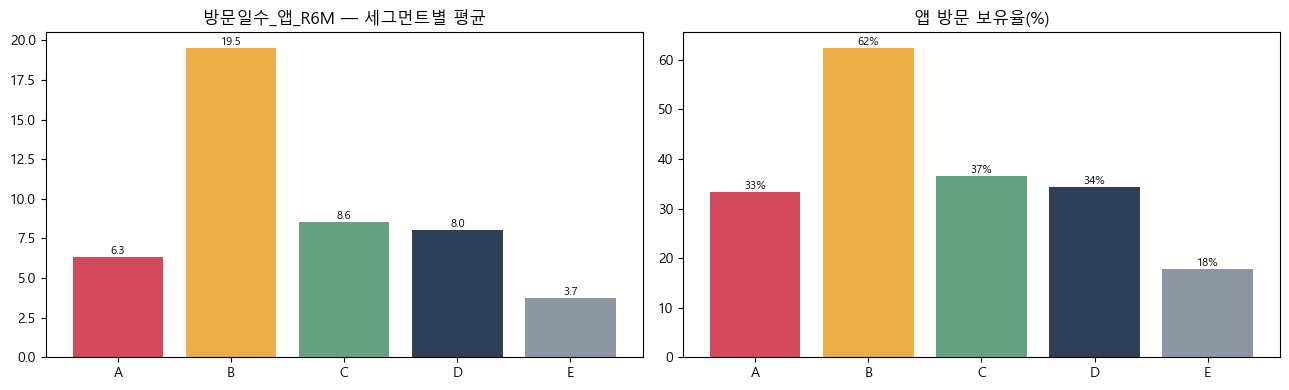

In [6]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
m1 = df.groupby('Segment')['방문일수_앱_R6M'].mean().reindex(SEG_ORDER)
ax[0].bar(SEG_ORDER, m1.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
ax[0].set_title('방문일수_앱_R6M — 세그먼트별 평균')
for i,v in enumerate(m1.values): ax[0].text(i,v,f'{v:.1f}',ha='center',va='bottom',fontsize=8)
app_rate=(df.assign(x=(df['방문일수_앱_R6M']>0)).groupby('Segment')['x'].mean().reindex(SEG_ORDER)*100)
ax[1].bar(SEG_ORDER, app_rate.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
ax[1].set_title('앱 방문 보유율(%)')
for i,v in enumerate(app_rate.values): ax[1].text(i,v,f'{v:.0f}%',ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()

## 4. Segment를 잘 가르는 수치형 피처 랭킹

In [7]:
drop=set(const_cols)|{'기준년월'}
num_cols=[c for c in df.columns if c not in drop and c not in ('ID','Segment') and pd.api.types.is_numeric_dtype(df[c])]
print('수치형 분석 대상:', len(num_cols))
med=df.groupby('Segment')[num_cols].median().reindex(SEG_ORDER).T
mean_=df.groupby('Segment')[num_cols].mean().reindex(SEG_ORDER).T
iqr=(df[num_cols].quantile(0.75)-df[num_cols].quantile(0.25)).replace(0,np.nan)
sep=((med.max(axis=1)-med.min(axis=1))/(iqr+1e-9)).sort_values(ascending=False)
# 0-inflated로 median이 다 0이면 sep=NaN → 평균 기반 분리도 보조
sep_mean=((mean_.max(axis=1)-mean_.min(axis=1))/(df[num_cols].std()+1e-9)).sort_values(ascending=False)
print('\n[중앙값 기반] 분리도 상위 12:')
ms=med.loc[sep.index]; ms.insert(0,'sep',sep.round(2)); print(ms.head(12).to_string())
print('\n[평균 기반] 분리도 상위 15 (0-inflated 대응):')
mm=mean_.loc[sep_mean.index]; mm.insert(0,'sep',sep_mean.round(3)); print(mm.head(15).round(1).to_string())

수치형 분석 대상: 46



[중앙값 기반] 분리도 상위 12:
Segment         sep     A     B     C     D     E
불만제기후경과월_R12M   0.0  12.0  12.0  12.0  12.0  12.0
인입일수_ARS_R6M    NaN   0.0   0.0   0.0   0.0   0.0
인입월수_ARS_R6M    NaN   0.0   0.0   0.0   0.0   0.0
인입후경과월_ARS      NaN   0.0   0.0   0.0   0.0   0.0
인입횟수_ARS_B0M    NaN   0.0   0.0   0.0   0.0   0.0
이용메뉴건수_ARS_B0M  NaN   0.0   0.0   0.0   0.0   0.0
인입일수_ARS_B0M    NaN   0.0   0.0   0.0   0.0   0.0
방문월수_PC_R6M     NaN   0.0   0.5   0.0   0.0   0.0
방문후경과월_PC_R6M   NaN   6.0   6.0   6.0   6.0   6.0
방문일수_앱_R6M      NaN   0.0  16.5   0.0   0.0   0.0
방문월수_앱_R6M      NaN   0.0   5.0   0.0   0.0   0.0
방문후경과월_앱_R6M    NaN   6.0   0.0   6.0   6.0   6.0

[평균 기반] 분리도 상위 15 (0-inflated 대응):
Segment         sep    A     B    C    D    E
홈페이지_선결제건수_R6M  2.0  2.3   7.5  2.4  2.0  0.8
홈페이지_선결제건수_R3M  1.9  1.2   3.7  1.2  1.0  0.4
홈페이지_금융건수_R6M   1.8  2.1   4.8  1.9  1.5  0.6
홈페이지_금융건수_R3M   1.6  1.0   2.3  1.0  0.8  0.3
방문횟수_앱_B0M      1.5  1.5   4.6  2.0  1.8  0.9
방문일수_앱_R6M      1

## 5. 범주형 / 구간형 채널 피처 vs Segment

In [8]:
cat_cols=[c for c in ['방문횟수_앱_R6M','인입횟수_ARS_R6M','이용메뉴건수_ARS_R6M',
                      '방문횟수_PC_R6M','OS구분코드'] if c in df.columns]
for c in cat_cols:
    ct=pd.crosstab(df[c],df['Segment']).reindex(columns=SEG_ORDER,fill_value=0)
    row_pct=(ct.div(ct.sum(axis=1),axis=0)*100).round(1); out=row_pct.copy(); out['n']=ct.sum(axis=1)
    print(f'\n=== {c} : 값별 세그먼트 구성비(%) ===')
    print(out.sort_values('n',ascending=False).to_string())


=== 방문횟수_앱_R6M : 값별 세그먼트 구성비(%) ===
Segment       A    B     C     D     E       n
방문횟수_앱_R6M                                    
1회 이상       0.0  0.0   4.5  12.5  83.0  326938
10회 이상      0.1  0.0   8.0  21.3  70.6   21696
20회 이상      0.0  0.0   8.0  21.2  70.7   20646
30회 이상      0.0  0.0   8.7  25.0  66.3   11560
40회 이상      0.1  0.1  10.8  27.2  61.8    9035
50회 이상      0.1  0.0  11.8  29.9  58.2    5296
60회 이상      0.1  0.1  12.9  31.4  55.6    3455
70회 이상      0.2  0.2  16.4  32.5  50.8    1245
80회 이상      0.0  0.0  26.4  22.5  51.2     129

=== 인입횟수_ARS_R6M : 값별 세그먼트 구성비(%) ===
Segment         A    B     C     D     E       n
인입횟수_ARS_R6M                                    
1회 이상         0.0  0.0   5.0  14.0  80.9  386268
10회 이상        0.1  0.0  14.2  29.3  56.3   13732



=== 이용메뉴건수_ARS_R6M : 값별 세그먼트 구성비(%) ===
Segment           A    B     C     D     E       n
이용메뉴건수_ARS_R6M                                    
1회 이상           0.0  0.0   4.9  13.8  81.2  375869
30회 이상          0.1  0.0  15.3  30.5  54.1   10172
10회 이상          0.1  0.0   7.8  19.8  72.4    7945
20회 이상          0.1  0.0  10.5  25.4  64.0    6014

=== 방문횟수_PC_R6M : 값별 세그먼트 구성비(%) ===
Segment        A    B     C     D     E       n
방문횟수_PC_R6M                                    
1회 이상        0.0  0.0   4.6  13.6  81.8  369084
30회 이상       0.1  0.0  13.8  26.3  59.8   22746
20회 이상       0.3  0.0  13.7  28.3  57.6    4103
10회 이상       0.2  0.0  10.9  25.4  63.4    3331
40회 이상       0.1  0.1  12.6  25.1  62.0     736



=== OS구분코드 : 값별 세그먼트 구성비(%) ===
Segment    A    B     C     D     E      n
OS구분코드                                    
Android  0.1  0.0   9.0  23.9  67.1  99058
IOS      0.1  0.0  10.2  26.2  63.5  28681


## 6. 소수클래스 A / B

In [9]:
a_mean=df[df['Segment']=='A'][num_cols].mean(); b_mean=df[df['Segment']=='B'][num_cols].mean(); g_mean=df[num_cols].mean()
cmp=pd.DataFrame({'A_mean':a_mean.round(2),'B_mean':b_mean.round(2),'ALL_mean':g_mean.round(2)})
cmp['A_vs_B_absdiff']=(a_mean-b_mean).abs()
print('=== A vs B 평균 차이 큰 피처 상위 15 ===')
print(cmp.sort_values('A_vs_B_absdiff',ascending=False).head(15).to_string())

=== A vs B 평균 차이 큰 피처 상위 15 ===
                A_mean  B_mean  ALL_mean  A_vs_B_absdiff
방문일수_앱_R6M        6.35   19.54      4.62       13.195988
홈페이지_선결제건수_R6M    2.35    7.46      1.06        5.112654
당사멤버쉽_방문횟수_R6M    8.73   13.71      8.38        4.973765
방문횟수_앱_B0M        1.51    4.58      1.06        3.077160
홈페이지_금융건수_R6M     2.09    4.75      0.82        2.657407
홈페이지_선결제건수_R3M    1.15    3.71      0.54        2.554012
방문일수_앱_B0M        1.17    3.46      0.85        2.285494
당사멤버쉽_방문횟수_B0M    1.25    3.46      1.51        2.211420
방문후경과월_앱_R6M      4.19    2.21      4.76        1.983025
방문월수_앱_R6M        1.45    3.38      1.12        1.924383
인입횟수_IB_R6M       1.09    2.42      0.55        1.324074
홈페이지_금융건수_R3M     1.02    2.33      0.42        1.308642
상담건수_R6M          2.07    3.33      0.91        1.265432
인입일수_ARS_R6M      1.43    2.62      0.63        1.199074
방문월수_PC_R6M       1.68    2.38      0.52        0.695988


## 7. 요약 & 발견

### 정보 밀도 낮음 — 105개 중 52개 상수
IB 문의·불만·VOC·금감원 계열이 이 표본에서 전부 0(상수). **실질 신호는 앱/웹 방문·ARS·홈페이지·멤버십 ~15개 컬럼에 집중.** 대부분 0-inflated이라 median은 0 → **평균(mean) 기반으로 봐야 함.**

### 채널 활동은 순서형(A→E)이 아님 — E(휴면) 식별 축
- 활동량은 A→E 단조가 아니다. `방문일수_앱_R6M` 평균: A 6.3 · **B 19.5** · C 8.6 · D 8.0 · E 3.7. A는 중간 수준, **C/D가 A보다 활발**하기도.
- 일관된 건 **E가 모든 채널에서 최저**(앱 보유율 E 17.8% vs 나머지 33%+). → 채널 활동의 주 용도는 **휴면 E 분리**(소비 피처와 상관되지만 방향은 engagement).
- 구간형(앱/ARS/PC 방문 '10·20·30회 이상')이 높을수록 **C·D 집중**, 낮은 '1회 이상'은 E 81%+. 헤비 채널 이용자는 중간 등급.

### ★ 새 B 지문 — B = 압도적 디지털 헤비유저 + 온라인 선결제
- `방문일수_앱_R6M` **B 19.5 (A의 3배)**, 앱 방문 보유율 **B 62.5%** vs A 33%, E 18%.
- `홈페이지_선결제건수_R6M` **B 7.5** vs A 2.3, `홈페이지_금융건수` B 4.8 vs A 2.1. `상담건수` B 3.3 최고.
→ 04(선결제)·05(할부)와 일관: **B는 앱/웹으로 활발히 관리하며 온라인 선결제하는 액티브 고소비 고객.** A vs B에서 앱/홈페이지 활동이 최대 차이 피처(방문일수_앱 absdiff 13.2).

### OS / 기타
`OS구분코드`(68% 결측=앱미사용)는 신호 약함(Android E 67% vs IOS 63.5%).

### 전처리 메모
- **상수 52개 제거**(카테고리 전체의 절반). 남는 ~46개 중에서도 실효는 앱/웹/홈페이지/ARS/멤버십.
- 0-inflated → 보유 플래그 + 활동량 값. 구간 문자열('N회 이상')은 순서 인코딩.
- 저정보 카테고리이므로 피처 선택 시 우선순위 낮게, 단 **E 휴면 플래그·B 디지털 활동**은 유지 가치.

**다음 카테고리**: 7.마케팅정보 (받은 마케팅 접촉).